In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
mnist=keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train,x_test=x_train/255.0,x_test/255.0

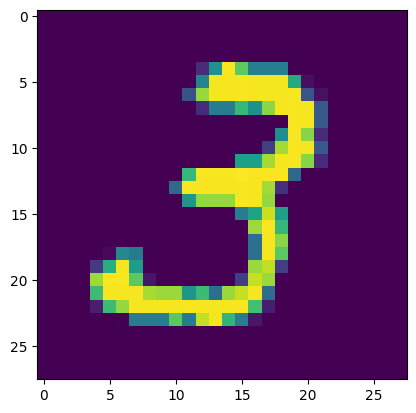

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[59996])

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
y_train.shape

(60000,)

In [ ]:
model=keras.Sequential(
    [
     keras.layers.Flatten(input_shape=(28,28,1)),
     keras.layers.Dense(128,activation='relu'),
     keras.layers.Dense(10,activation='softmax')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,validation_split=0.1,epochs=15)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9955 - loss: 0.0149 - val_accuracy: 0.9800 - val_loss: 0.0930
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9959 - loss: 0.0126 - val_accuracy: 0.9797 - val_loss: 0.0958
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9974 - loss: 0.0096 - val_accuracy: 0.9792 - val_loss: 0.0987
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9969 - loss: 0.0099 - val_accuracy: 0.9802 - val_loss: 0.0970
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9974 - loss: 0.0086 - val_accuracy: 0.9767 - val_loss: 0.1108
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9977 - loss: 0.0076 - val_accuracy: 0.9815 - val_loss: 0.1016
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9976 - loss: 0.0073 - val_accuracy: 0.9797 - val_loss: 0.1103
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9979 - loss: 0.

Text(0, 0.5, 'epoch')

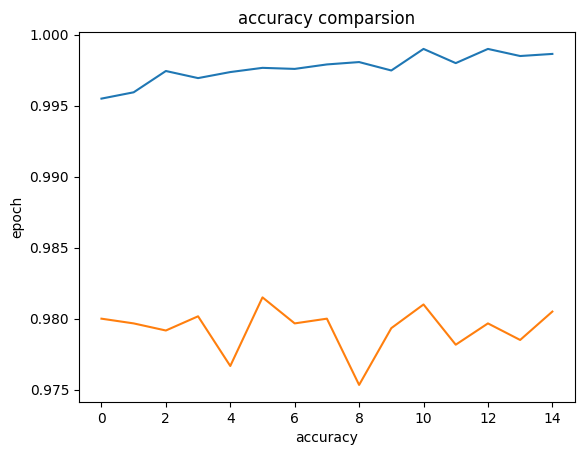

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("accuracy comparsion")
plt.xlabel("accuracy")
plt.ylabel("epoch")

Text(0, 0.5, 'epoch')

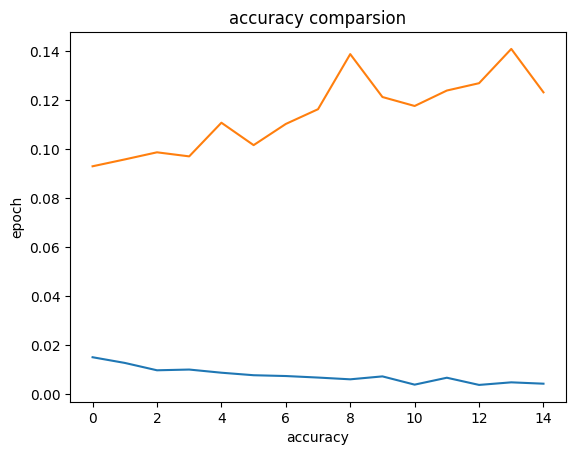

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("accuracy comparsion")
plt.xlabel("accuracy")
plt.ylabel("epoch")

In [ ]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred[9999]

array([6.3829554e-20, 2.7631415e-31, 1.3853296e-17, 2.3596415e-21,
       6.2792626e-13, 3.3352328e-18, 9.9999994e-01, 2.8373838e-27,
       1.7362978e-20, 2.7006755e-33], dtype=float32)

In [ ]:
import numpy as np
val=np.argmax(y_pred,axis=1)
val[8342]

np.int64(0)

Text(0.5, 1.0, 'y_test: 3 y_pred: 3')

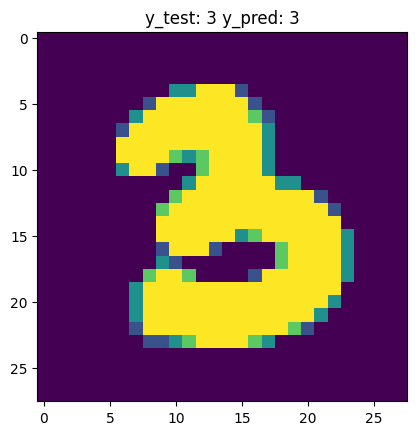

In [ ]:
plt.imshow(x_test[894])
plt.title(f"y_test: {y_test[894]} y_pred: {val[894]}")


In [ ]:
model.save("mnist_model.h5")

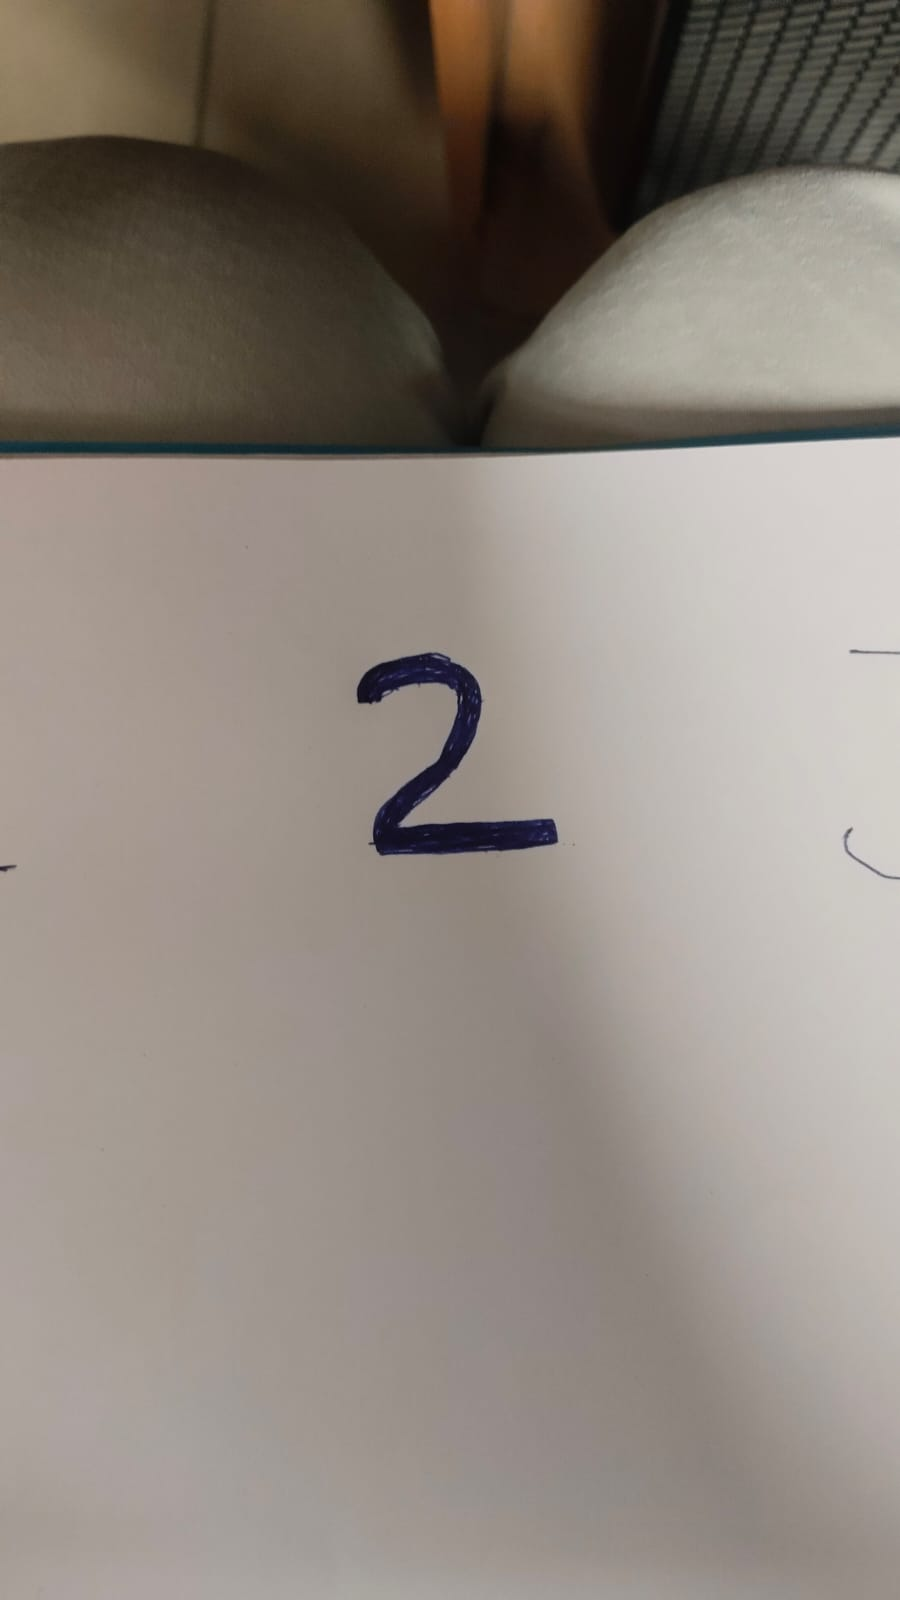

In [ ]:
import cv2
df=cv2.imread("/content/drive/MyDrive/MLT/imgae.jpeg")
from google.colab.patches import cv2_imshow
cv2_imshow(df)

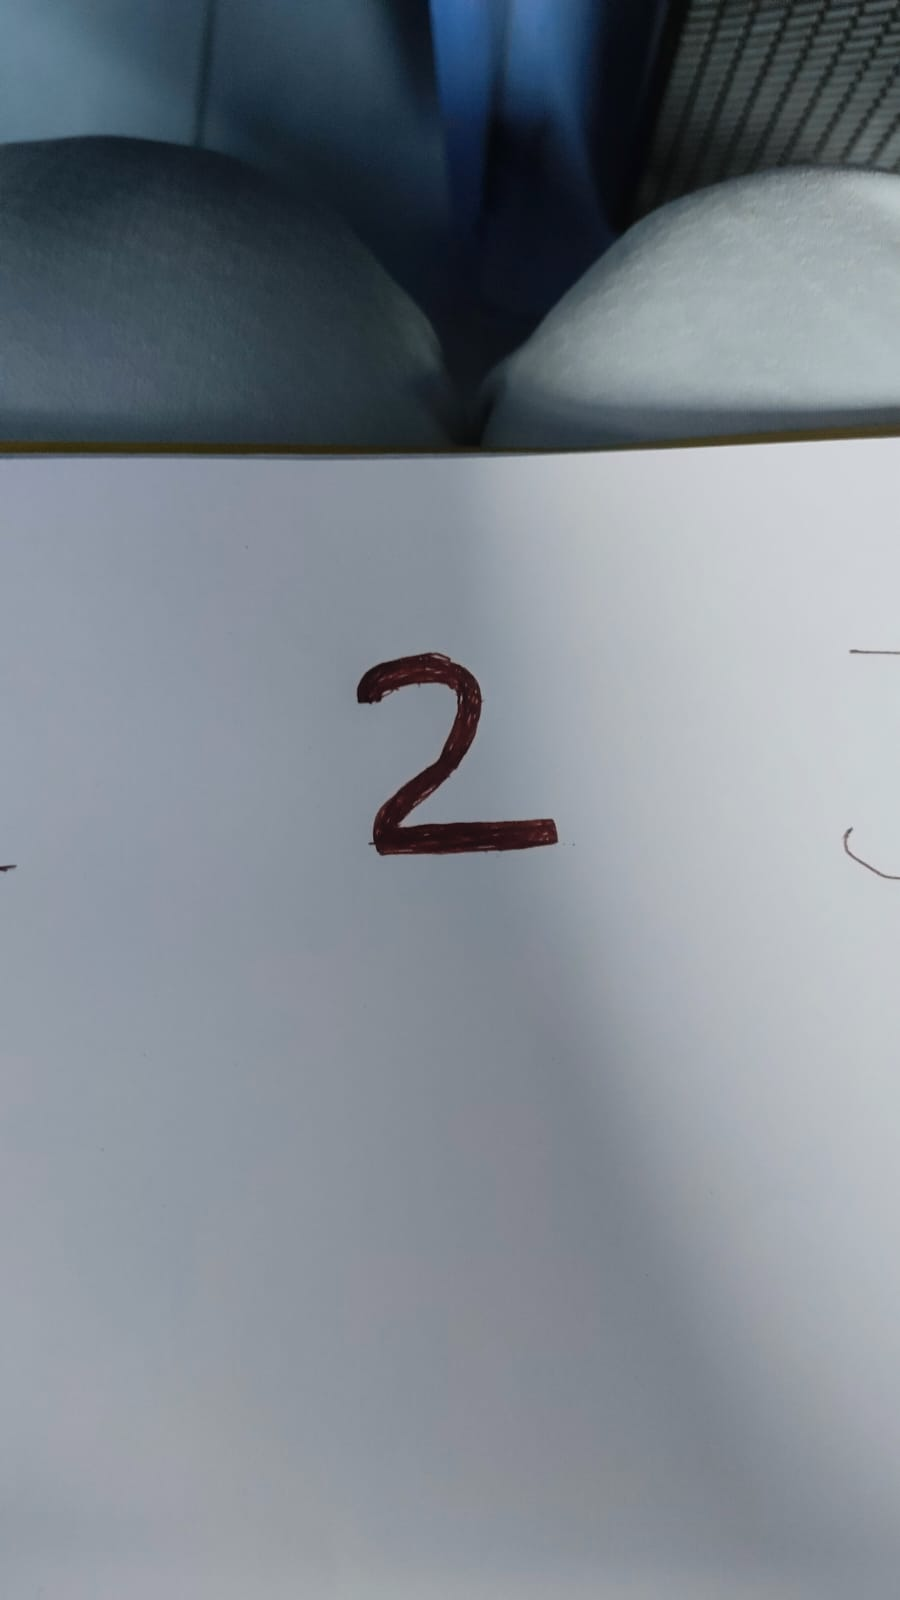

In [ ]:
from google.colab.patches import cv2_imshow
ims=cv2.cvtColor(df,cv2.COLOR_RGB2BGR)
cv2_imshow(ims)

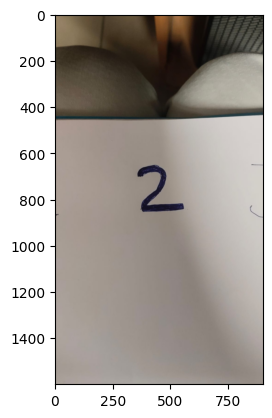

In [ ]:
plt.imshow(ims, cmap="gray")
plt.show()

In [ ]:
print(model.input_shape)
print(model.summary())

(None, 28, 28, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

None


In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

print("Model Inputs:", model.inputs)
print("Model Outputs:", model.outputs)

print("Input Shape:", model.input_shape)
print("Output Shape:", model.output_shape)

TensorFlow: 2.20.0
Model Inputs: [<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]
Model Outputs: [<KerasTensor shape=(None, 10), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>]
Input Shape: (None, 28, 28, 1)
Output Shape: (None, 10)


In [ ]:
print(type(img))
print(img.shape)
print(img.dtype)

<class 'numpy.ndarray'>
(1, 28, 28, 1)
float32


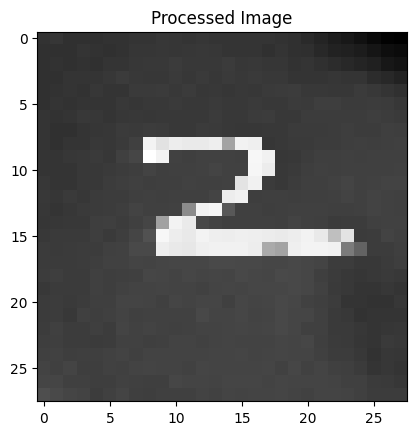

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Predicted Digit: 3
Confidence: 0.9979867


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/drive/MyDrive/MLT/img.jpeg", cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (28, 28))

# Invert colors if digit is black on white background
img = 255 - img

# Normalize
img = img / 255.0

# Display processed image
plt.imshow(img, cmap='gray')
plt.title("Processed Image")
plt.show()

# Reshape for model
img = img.reshape(1, 28, 28)

# Prediction
y_pred = model.predict(img)

# Predicted digit
digit = np.argmax(y_pred)

print("Predicted Digit:", digit)
print("Confidence:", np.max(y_pred))